Install required libraries

In [1]:
pip install folium --break-system-packages

Import libraries and load data

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('data.csv', encoding='latin1')

print(df.shape)
print(df.head())
print(df.info())
print(df.describe())

(152618, 13)
  stn_code       sampling_date           state   location agency  \
0    150.0  February - M021990  Andhra Pradesh  Hyderabad    NaN   
1    151.0  February - M021990  Andhra Pradesh  Hyderabad    NaN   
2    152.0  February - M021990  Andhra Pradesh  Hyderabad    NaN   
3    150.0     March - M031990  Andhra Pradesh  Hyderabad    NaN   
4    151.0     March - M031990  Andhra Pradesh  Hyderabad    NaN   

                                 type  so2   no2  rspm  spm  \
0  Residential, Rural and other Areas  4.8  17.4   NaN  NaN   
1                     Industrial Area  3.1   7.0   NaN  NaN   
2  Residential, Rural and other Areas  6.2  28.5   NaN  NaN   
3  Residential, Rural and other Areas  6.3  14.7   NaN  NaN   
4                     Industrial Area  4.7   7.5   NaN  NaN   

  location_monitoring_station  pm2_5        date  
0                         NaN    NaN  1990-02-01  
1                         NaN    NaN  1990-02-01  
2                         NaN    NaN  1990-02-

Check missing values

In [5]:
print(df.isnull().sum())
print(df.isnull().sum() / len(df) * 100)

stn_code                        53113
sampling_date                       0
state                               0
location                            0
agency                          54645
type                             1634
so2                             15216
no2                              6314
rspm                            14550
spm                             80052
location_monitoring_station      9580
pm2_5                          148369
date                                2
dtype: int64
stn_code                       34.801269
sampling_date                   0.000000
state                           0.000000
location                        0.000000
agency                         35.805082
type                            1.070647
so2                             9.969990
no2                             4.137127
rspm                            9.533607
spm                            52.452529
location_monitoring_station     6.277110
pm2_5                          97.215925
d

Clean the data

In [7]:
df['date'] = pd.to_datetime(df['date'])
df['Year'] = df['date'].dt.year
df['Month'] = df['date'].dt.month
df['Month_Name'] = df['date'].dt.month_name()

# df_clean = df.dropna(subset=['AQI']) # 'AQI' column not found, please clarify which column to use.
df_clean = df.drop_duplicates()

print("Cleaned shape:", df_clean.shape)

Cleaned shape: (152301, 16)


Q1 — Most polluted state:

In [20]:
state_pollution = df_clean.groupby('state')['rspm'].mean().sort_values(ascending=False)
print(state_pollution.head(10))

state
Delhi               196.639771
Jharkhand           168.517763
Haryana             149.876916
Chhattisgarh        126.472399
Bihar               123.673929
Jammu & Kashmir     117.449483
Gujarat              98.256770
Chandigarh           96.587079
Assam                93.724912
Himachal Pradesh     91.851330
Name: rspm, dtype: float64


Q2 — Monthly pollution trend:

In [19]:
monthly = df_clean.groupby('Month_Name')['rspm'].mean().sort_values(ascending=False)
print(monthly)

Month_Name
December     112.659347
January      108.085791
March        107.822958
February     107.807922
November     106.065769
May          103.444535
April        103.381580
October       97.998580
June          94.457229
July          86.156633
September     85.775801
August        83.293715
Name: rspm, dtype: float64


Q3 —Pollution trend over years:





In [27]:
start = df_clean[df_clean['Year'] == 1990]['rspm'].mean()
end = df_clean[df_clean['Year'] == 2015]['rspm'].mean()
change = ((end - start) / start * 100).round(2)
print(f"1990 avg pollution: {start:.2f}")
print(f"2015 avg pollution: {end:.2f}")
print(f"Change over 25 years: {change}%")

1990 avg pollution: nan
2015 avg pollution: 91.04
Change over 25 years: nan%


Q4 — Pollutant correlation:

In [17]:
pollutants = ['so2', 'no2', 'rspm', 'spm', 'pm2_5']
correlation = df_clean[pollutants].corr()['rspm'].sort_values(ascending=False)
print(correlation)

rspm     1.000000
pm2_5    0.835023
spm      0.817498
no2      0.484026
so2      0.226809
Name: rspm, dtype: float64


Q5 — Top 10 polluted cities:

In [18]:
city_pollution = df_clean.groupby('location')['rspm'].mean().sort_values(ascending=False)
print(city_pollution.head(10))

location
West Singhbhum         246.417219
Jharia                 210.844414
Raipur                 210.202634
Delhi                  196.639771
Baroda                 179.238702
Yamunanagar            177.579710
Ranchi                 175.361074
Faridabad              170.536977
Saraikela Kharsawan    162.863248
Dhanbad                161.890142
Name: rspm, dtype: float64


Chart 1: Top 10 Polluted States

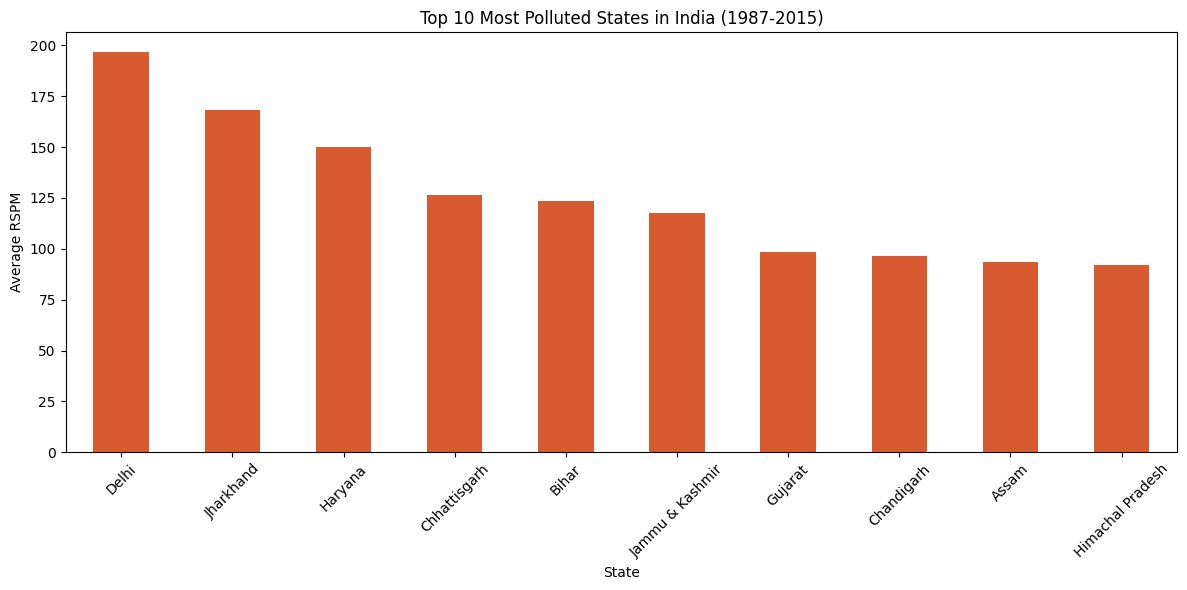

Chart 1 saved!


In [21]:
plt.figure(figsize=(12, 6))
state_pollution.head(10).plot(kind='bar', color='#D85A30')
plt.title('Top 10 Most Polluted States in India (1987-2015)')
plt.xlabel('State')
plt.ylabel('Average RSPM')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('polluted_states.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved!")

Chart 2: Monthly Pollution Trend

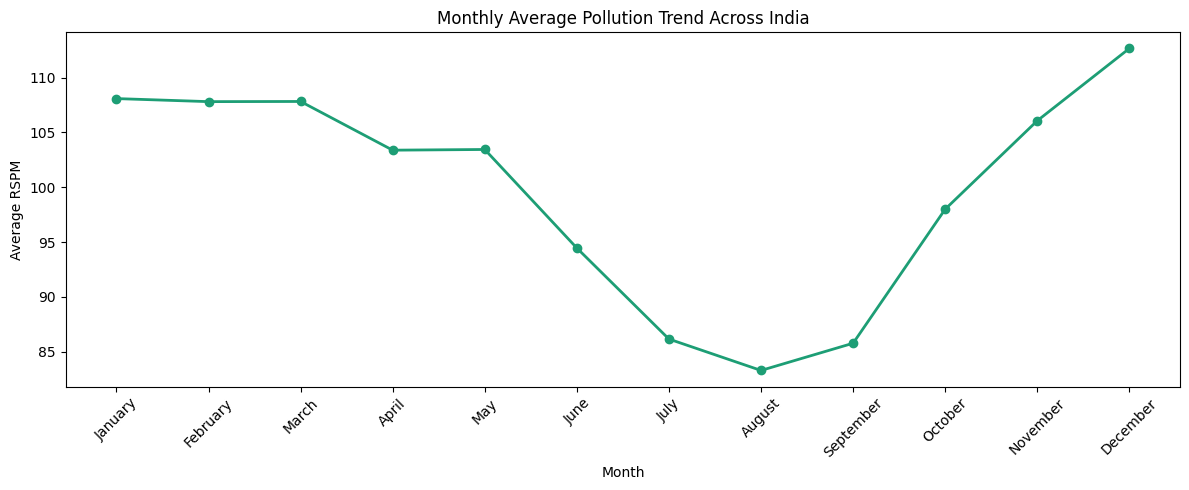

Chart 2 saved!


In [22]:
month_order = ['January','February','March','April','May',
               'June','July','August','September','October',
               'November','December']

monthly_ordered = df_clean.groupby('Month_Name')['rspm'].mean().reindex(month_order)

plt.figure(figsize=(12, 5))
plt.plot(monthly_ordered.index, monthly_ordered.values,
         marker='o', color='#1D9E75', linewidth=2)
plt.title('Monthly Average Pollution Trend Across India')
plt.xlabel('Month')
plt.ylabel('Average RSPM')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved!")

Chart 3: Yearly Pollution Trend

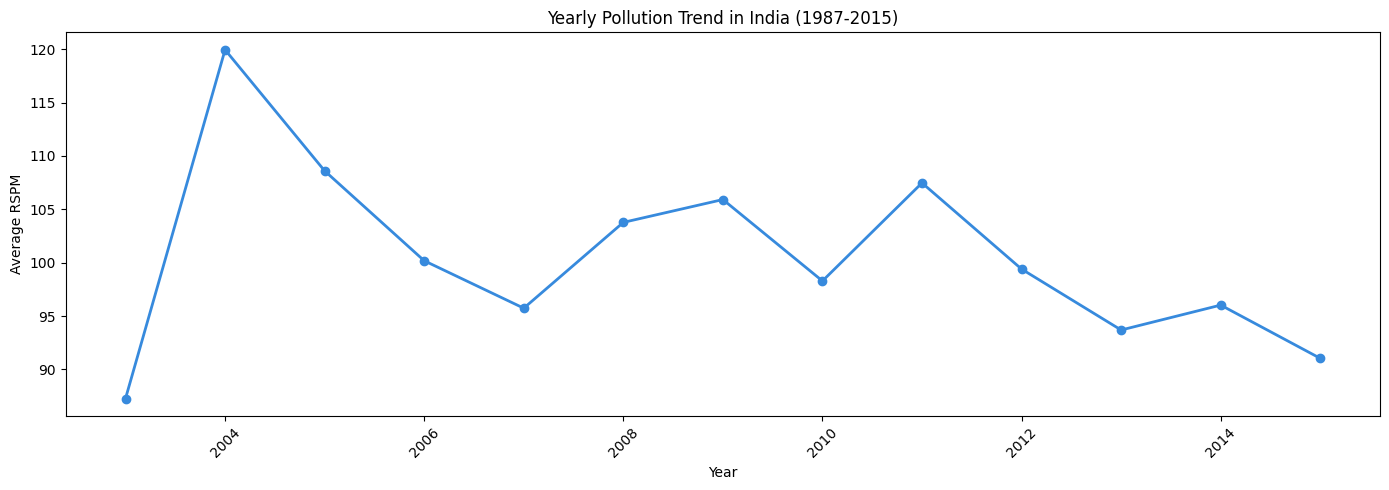

Chart 3 saved!


In [23]:
yearly = df_clean.groupby('Year')['rspm'].mean().dropna()

plt.figure(figsize=(14, 5))
plt.plot(yearly.index, yearly.values,
         marker='o', color='#378ADD', linewidth=2)
plt.title('Yearly Pollution Trend in India (1987-2015)')
plt.xlabel('Year')
plt.ylabel('Average RSPM')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('yearly_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved!")

Chart 4: Pollutant Correlation Heatmap

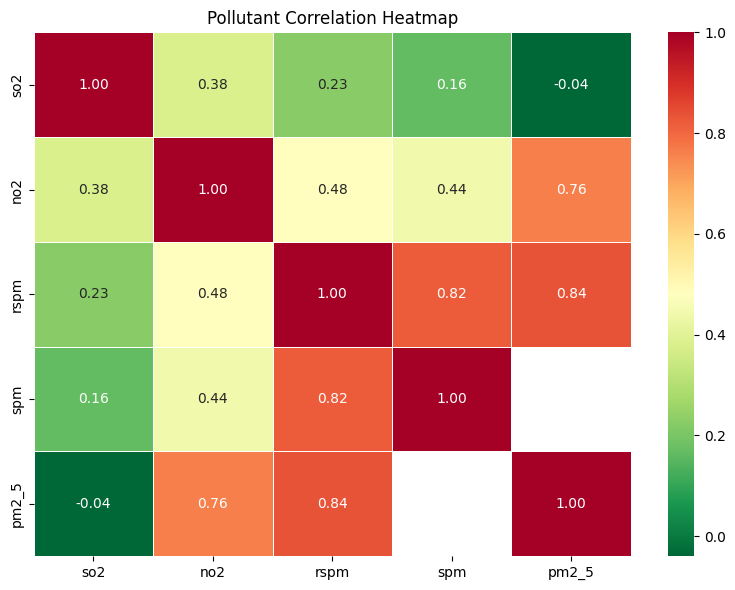

Chart 4 saved!


In [24]:
plt.figure(figsize=(8, 6))
pollutant_cols = ['so2', 'no2', 'rspm', 'spm', 'pm2_5']
corr_data = df_clean[pollutant_cols].corr()

sns.heatmap(corr_data,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn_r',
            linewidths=0.5)
plt.title('Pollutant Correlation Heatmap')
plt.tight_layout()
plt.savefig('heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 4 saved!")

Chart 5: India Pollution Map

In [25]:
city_coords = {
    'Delhi': [28.6139, 77.2090],
    'Mumbai': [19.0760, 72.8777],
    'Bangalore': [12.9716, 77.5946],
    'Chennai': [13.0827, 80.2707],
    'Kolkata': [22.5726, 88.3639],
    'Hyderabad': [17.3850, 78.4867],
    'Ahmedabad': [23.0225, 72.5714],
    'Pune': [18.5204, 73.8567],
    'Lucknow': [26.8467, 80.9462],
    'Patna': [25.5941, 85.1376]
}

m = folium.Map(location=[20.5937, 78.9629], zoom_start=5)

for city, coords in city_coords.items():
    city_data = df_clean[df_clean['location'].str.contains(city,
                          case=False, na=False)]
    if len(city_data) > 0:
        rspm_val = city_data['rspm'].mean()
        if not pd.isna(rspm_val):
            color = 'red' if rspm_val > 200 else \
                    'orange' if rspm_val > 100 else 'green'
            folium.CircleMarker(
                location=coords,
                radius=float(rspm_val)/15,
                color=color,
                fill=True,
                fill_opacity=0.7,
                popup=f"{city}: RSPM {rspm_val:.0f}"
            ).add_to(m)

m.save('india_air_quality_map.html')
print("Map saved!")

Map saved!


In [26]:
from google.colab import files
files.download('polluted_states.png')
files.download('monthly_trend.png')
files.download('yearly_trend.png')
files.download('heatmap.png')
files.download('india_air_quality_map.html')
print("All files downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All files downloaded!
